In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[1])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import TotalVariationRecon, L1WaveletRecon
from scipy.io import savemat, loadmat
import twixtools
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.signal import butter,filtfilt


## My files
from ksp_plot_helpers import plot_ksp_data_multichannel, find_and_plot_acquired_region
from raw_data_utils import get_kspace_data, get_TR
from resp_signal_functions import resp_signal_all_slices, resp_signal_single_slice, resp_signal_center_sample_single_slice
from resp_signal_plot_functions import *
import gating_functions
from pca_helper import pca_resp_signal
from save_data_helpers import *

### Data Loading

Average value, slices vs samples per gate = 3.577272582333535e-05
Average value, readouts vs spokes per gate = 3.644393291324377e-05
Average value, slices vs center sample per gate = 0.00014447004650719464


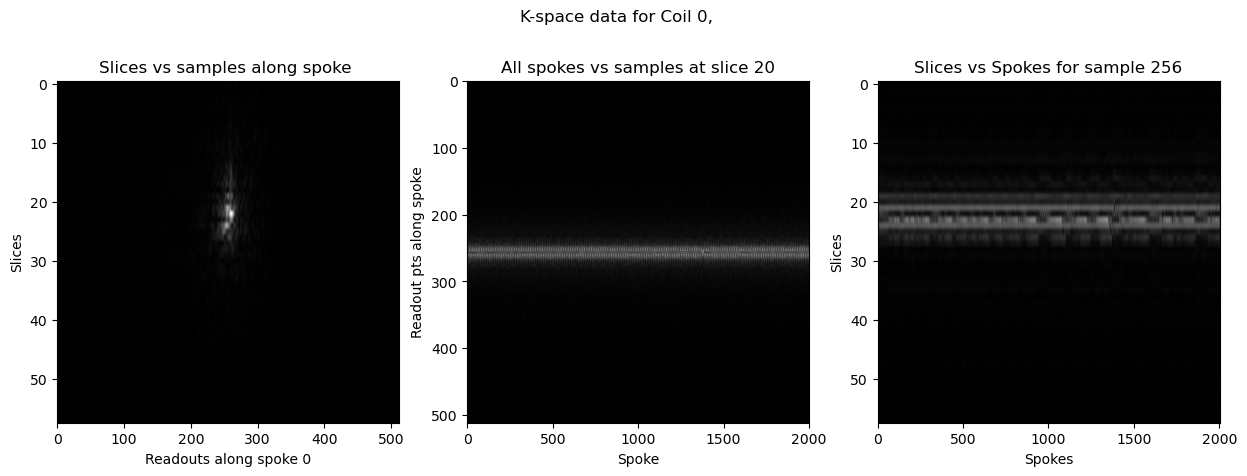

In [2]:
ksp_512 = read_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/ksp_from_mdb_512_samples.pkl')
ksp_512 = np.transpose(ksp_512, (2, 0, 1, 3))
fig, axs = plot_ksp_data_multichannel(ksp_data=ksp_512, coil_idx=0, center_slice=20, center_sample=256)

In [3]:
resp_data_mat = loadmat('/home/lilianae/projects/naf_clean/matlab_comparison/resp_trace_gates_pt2.mat')
resp_trace = resp_data_mat['resp_signal'].ravel()
print(f'resp_trace.shape = {resp_trace.shape}')

resp_trace.shape = (2002,)


### Respiatory trace processing

In [12]:
# gibbs_factor = 0.08
# buffer = int(np.round(len(resp_trace)*gibbs_factor/2))
# print(buffer)

# ### Sort resp signal making indices of resp amplitude into the trace
# resp_ind = np.argsort(resp_trace[buffer:-buffer])
# print(resp_ind)
# resp_signal_sort = resp_trace[buffer:-buffer][resp_ind]

# ## Debug checks
# print("buffer:", buffer, type(buffer))
# print("resp_trace shape:", resp_trace.shape)
# print("resp_trace[buffer:-buffer] shape:", resp_trace[int(buffer):-int(buffer)].shape)
# print("Sliced data:", resp_trace[int(buffer):-int(buffer)])
# print("argsort result:", np.argsort(resp_trace[int(buffer):-int(buffer)]))

In [ ]:
# print(resp_ind)

In [ ]:
# ## Make list of gates: 0=skip, gates 1-n are inspiration to expiration
# resp_gates = np.zeros(resp_trace.shape)
# acq_order = np.linspace(0, len(resp_trace), len(resp_trace))

# ## Trim outlier deep breaths
# signal_deep_breath = 0.021
# ind_deep_breath = np.where(resp_signal_sort < signal_deep_breath)

# ## Choose number of gates
# num_gates = 5
# ## Select gates based on even number of samples
# num_samples_per_gate = np.tile(int(np.floor((len(resp_signal_sort) - len(ind_deep_breath))/num_gates)), (num_gates,1))


# # Add the number of deep breaths to gate 1
# num_samples_per_gate[0] = num_samples_per_gate[0] + len(ind_deep_breath)

# ## Check number of samples in the last for rounding errors
# num_samples_per_gate[num_gates-1] = len(resp_signal_sort) - np.sum(num_samples_per_gate[0:num_gates-1])

# num_samples_per_gate = num_samples_per_gate.reshape(-1)


# print(f'num_samples_per_gate = {num_samples_per_gate}')


In [ ]:
# ## Assign gate numbers to the list of gates
# for n in range(num_gates):
#     for p in range(num_samples_per_gate[n]):
#         r = np.sum(num_samples_per_gate[0:n-1])+p
#         resp_gates[buffer+resp_ind[r]] = n+1

# resp_gates[buffer + resp_ind[ind_deep_breath]] = 0

# print(resp_gates[1900:2000])

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Plot spokes in each of the n gates
# plot_strings = ['ob', 'oc', 'om', 'or', 'og', 'oy']

# plt.figure(11)
# plt.plot(acq_order, resp_trace, '-o', label='Resp. trace', markersize=0.5)

# for n in range(num_gates + 1):
#     tmp = np.where(resp_gates == n)[0]  # Note: n, not n-1 (Python is 0-based)
#     resp_single_gate = resp_trace[tmp]
#     resp_single_gate_acq_order = acq_order[tmp]
    
#     # Get label based on n
#     if n == 0:
#         label = 'Reject'
#     else:
#         label = f'Gate {n}'
    
#     plt.plot(resp_single_gate_acq_order, resp_single_gate, 
#              plot_strings[n], label=label, markersize=1)

# plt.xlabel('Acq. order')
# plt.ylabel('Resp. amplitude')
# plt.legend()
# plt.show()

In [ ]:
def create_ksp_gates_sparse(ksp_data, idx_all, num_gates):
    """
    Create gates for k-space data given len(idx) = num_spokes
    
    Inputs:
    -----------
    ksp_data : array, shape (num_coils, total_temporal_samples, num_samples)
        K-space data with combined temporal dimension
    idx_all : array, shape (num_spoke_groups,)
        Sparse gating indices where each index corresponds to num_slices consecutive spokes
    num_gates : int
        Number of respiratory gates
    num_slices : int
        Number of slices per spoke group
    
    Outputs:
    --------
    data_bins : list of arrays
        K-space data for each gate
    spoke_bins : list of arrays  
        Coordinate data for each gate
    """
    data_bins = []
    index_bins = []
    
    num_coils, num_slices, num_spokes, num_samples = ksp_data.shape
    kspace_temporal = ksp_data.transpose(0, 2, 1, 3).reshape(num_coils, num_slices * num_spokes, num_samples)

    for gate in range(1, num_gates + 1):
        # Find which spoke groups belong to this gate
        group_mask = (idx_all == gate)
        
        # Convert sparse mask to full temporal mask
        # Each True in group_mask corresponds to num_slices consecutive temporal samples
        # full_mask = np.zeros(len(idx_all) * num_slices, dtype=bool)
        full_mask = np.zeros(len(idx_all) * num_slices, dtype=bool)
        for i, is_gate in enumerate(group_mask):
            if is_gate:
                start_idx = i * num_slices
                end_idx = (i + 1) * num_slices
                full_mask[start_idx:end_idx] = True
        
        # Extract data for this gate
        current_ksp_data = kspace_temporal[:, full_mask, :]
        current_indices = np.where(full_mask)[0]
        
        data_bins.append(current_ksp_data)
        index_bins.append(current_indices)
        
        print(f"Gate {gate}: {np.sum(group_mask)} spoke groups, {np.sum(full_mask)} total spokes")
    
    return data_bins, index_bins

In [ ]:
def reshape_gate(data_bin, num_coils, num_slices, num_samples, ndims):
    """
    Reshape gated data back to (coils, spokes_per_slice, slices, samples) format.

    Inputs:
    ---------------------------
    data_bin: array, shape (num_coils, total_temporal_samples, num_samples)
        K-space data for one gate
    num_coils : int
        Number of coils
    num_slices : int
        Number of partitions 
    num_samples : int
        Number of readout points
    ndims : int
        Number of dimensions for coordinate system

    Outputs:
    ---------------------------
    data_bin: array, shape (num_coils, num_spokes, num_slices, num_samples)
        Reshaped data_bin
    
    spoke_bin: array, shape (num_spokes, num_slices, num_samples,, ndims)
        Reshaped spoke_bin

    """
    N = data_bin.shape[1]  # total spokes in this gate
    
    # Complete slice groups
    max_valid = (N // num_slices) * num_slices
    
    if max_valid < N:
        print(f"Warning: Truncating {N - max_valid} incomplete spokes to maintain slice structure")
    
    # Truncate to complete slice groups
    data_bin = data_bin[:, :max_valid, :]
    
    # Calculate spokes per slice for this gate
    num_spokes_per_slice = max_valid // num_slices
    
    # Reshape back to 4D
    data_bin = data_bin.reshape(num_coils, num_spokes_per_slice, num_slices, num_samples)
    
    return data_bin


In [ ]:
# data_bins_updated, index_bins_updated = create_ksp_gates_sparse(ksp_512, idx_all=resp_gates, num_gates=5)
# print(f'len(data_bins_updated) = {len(data_bins_updated)}')
# print(f'data_bins_updated[0].shape = {data_bins_updated[0].shape}')

### Alternative gating

In [4]:
p_gates_all= loadmat('/home/lilianae/projects/naf_clean/matlab_comparison/phil_gates.mat')
num_gates = 5
p_gates = []
for i in range(1, num_gates+1):
    gate_name = f'gate{i}'
    gate_data = p_gates_all[gate_name].ravel()
    print(f'gate_data.shape = {gate_data.shape}')
    p_gates.append(gate_data)

print(f'len(p_gates) = {len(p_gates)}')

gate_data.shape = (365,)
gate_data.shape = (365,)
gate_data.shape = (365,)
gate_data.shape = (365,)
gate_data.shape = (365,)
len(p_gates) = 5


In [5]:
def ga_2d_readout_from_spokes(kmax, spoke_list, num_points):
    """2D golden angle kspace trajectory"""
    tmp = np.linspace(-kmax, kmax, num_points)
    k = np.zeros((len(spoke_list), num_points, 2))
    
    ga = np.pi / ((1 + np.sqrt(5)) / 2)  # Golden angle
    
    for i in range(len(spoke_list)):
        # print(f'spoke[{i}] = {spoke_list[i]}')
        phi = (spoke_list[i] * ga) % (2 * np.pi)
        k[i, :, 0] = tmp * np.cos(phi)
        k[i, :, 1] = tmp * np.sin(phi)
    
    return k


def get_ga_coords_3d_from_spokes(img_shape, spoke_list, num_points):
    """Generate 3D stack-of-stars golden angle coordinates"""
    # Generate 2D golden angle spokes
    coords_2d = ga_2d_readout_from_spokes(img_shape[1]//2, spoke_list, num_points)
    
    # Stack across partitions with kz encoding
    shape_3d = [img_shape[0]] + list(coords_2d.shape)
    shape_3d[3] += 1  # Add dimension for kz
    
    coords_3d = np.zeros(shape_3d, dtype=coords_2d.dtype)
    slice_coords = np.linspace(-img_shape[0]/2., img_shape[0]/2., img_shape[0])
    
    for i in range(img_shape[0]):
        coords_3d[i, :, :, 1:] = coords_2d  # kx, ky
        coords_3d[i, :, :, 0] = slice_coords[i]  # kz
    
    return coords_3d

In [6]:
data_bins = []
spoke_bins = []
num_coils, num_slices, num_spokes, num_samples = ksp_512.shape
img_shape = (num_slices, num_samples, num_samples)

for i in range(num_gates):
    num_spokes_per_gate = len(p_gates[i])
    spokes_for_gate = p_gates[i]
    current_ksp = np.zeros((num_coils, num_slices, num_spokes_per_gate, num_samples), dtype=complex)

    current_coords = get_ga_coords_3d_from_spokes(img_shape=img_shape, spoke_list=spokes_for_gate, num_points=num_samples)

    for j,spoke in enumerate(spokes_for_gate):
        current_ksp[:, :, j, :] = ksp_512[:, :, spoke, :]

    print(f'Gate {i}:')
    print(f'current_coords.shape = {current_coords.shape}')
    print(f'current_ksp.shape - {current_ksp.shape}')

    data_bins.append(current_ksp)
    spoke_bins.append(current_coords)

Gate 0:
current_coords.shape = (58, 365, 512, 3)
current_ksp.shape - (15, 58, 365, 512)
Gate 1:
current_coords.shape = (58, 365, 512, 3)
current_ksp.shape - (15, 58, 365, 512)
Gate 2:
current_coords.shape = (58, 365, 512, 3)
current_ksp.shape - (15, 58, 365, 512)
Gate 3:
current_coords.shape = (58, 365, 512, 3)
current_ksp.shape - (15, 58, 365, 512)
Gate 4:
current_coords.shape = (58, 365, 512, 3)
current_ksp.shape - (15, 58, 365, 512)


Original shape: (15, 58, 365, 512)
ncoils=15, nslices=58, nsamples=512, nspokes=365
ksp_data_flat.shape = (15, 58, 186880)
Data min: 4.656612873077393e-10
Data max: 0.00140050925104471
Data mean: 8.635656758347092e-06
Data median: 2.7315172637653024e-06
Data std: 3.327591408677693e-05
Non-zero elements: 10839040 / 10839040


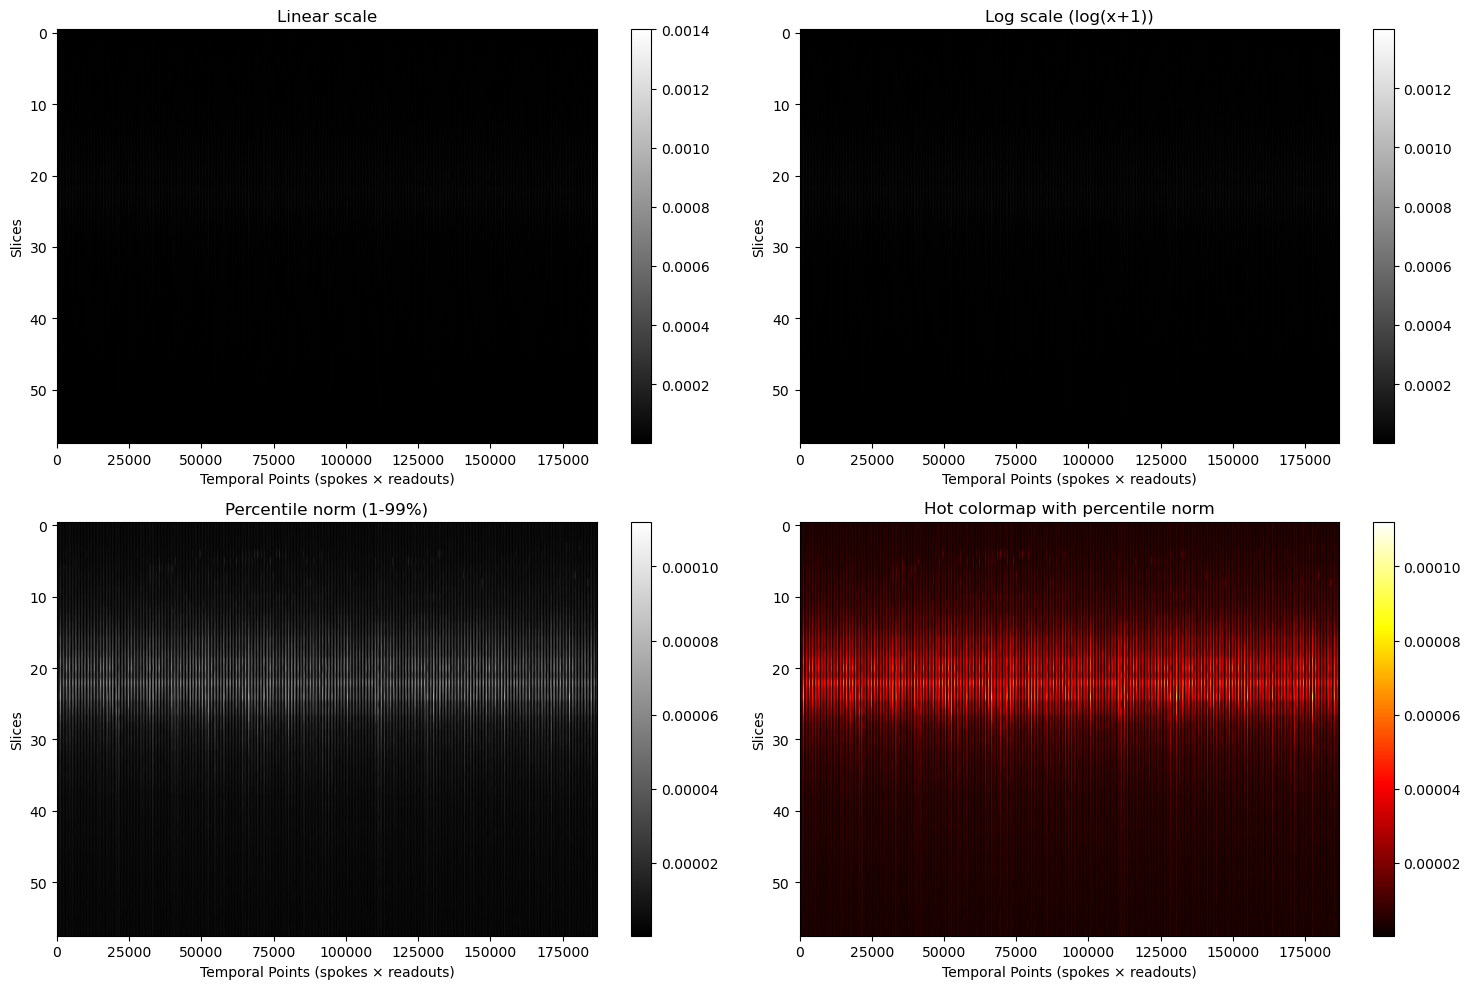

In [7]:
def plot_ksp_data_gate_debug(ksp_data, coil_idx, title=""):
    """Plot ksp data for slices vs (spoke,sample) dimension collapsed"""
    
    print(f"Original shape: {ksp_data.shape}")
    # Original: (ncoils, nspokes, nslices, nsamples)
    
    # ksp_data = ksp_data.transpose(0, 2, 1, 3)
    # print(f"After transpose: {ksp_data.shape}")
    
    ncoils, nslices, nspokes, nsamples = ksp_data.shape
    print(f"ncoils={ncoils}, nslices={nslices}, nsamples={nsamples}, nspokes={nspokes}")
    
    # Reshape to collapse spokes and samples into one temporal dimension
    ksp_data_flat = ksp_data.reshape(ncoils, nslices, -1)
    print(f"ksp_data_flat.shape = {ksp_data_flat.shape}")
    
    # Extract data for visualization
    plot_data = np.abs(ksp_data_flat[coil_idx, :, :])  # (nslices, temporal_pts)
    
    # DEBUGGING: Check data statistics
    print(f"Data min: {plot_data.min()}")
    print(f"Data max: {plot_data.max()}")
    print(f"Data mean: {plot_data.mean()}")
    print(f"Data median: {np.median(plot_data)}")
    print(f"Data std: {plot_data.std()}")
    print(f"Non-zero elements: {np.count_nonzero(plot_data)} / {plot_data.size}")
    
    # Try different visualizations to see what works
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Linear scale
    im1 = axes[0,0].imshow(plot_data, cmap='gray', aspect='auto')
    axes[0,0].set_title("Linear scale")
    plt.colorbar(im1, ax=axes[0,0])
    
    # Plot 2: Log scale
    im2 = axes[0,1].imshow(np.log(plot_data + 1), cmap='gray', aspect='auto')
    axes[0,1].set_title("Log scale (log(x+1))")
    plt.colorbar(im2, ax=axes[0,1])
    
    # Plot 3: Percentile-based normalization
    vmin, vmax = np.percentile(plot_data, [1, 99])
    im3 = axes[1,0].imshow(plot_data, cmap='gray', aspect='auto', 
                           vmin=vmin, vmax=vmax)
    axes[1,0].set_title(f"Percentile norm (1-99%)")
    plt.colorbar(im3, ax=axes[1,0])
    
    # Plot 4: Hot colormap (better for k-space)
    im4 = axes[1,1].imshow(plot_data, cmap='hot', aspect='auto',
                           vmin=vmin, vmax=vmax)
    axes[1,1].set_title("Hot colormap with percentile norm")
    plt.colorbar(im4, ax=axes[1,1])
    
    for ax in axes.flat:
        ax.set_xlabel("Temporal Points (spokes × readouts)")
        ax.set_ylabel("Slices")
    
    plt.tight_layout()
    plt.show()


plot_ksp_data_gate_debug(data_bins[0], coil_idx=8)

Average value, slices vs samples per gate = 1.5884891529925418e-05
Average value, readouts vs spokes per gate = 3.6825714470667715e-05
Average value, slices vs center sample per gate = 0.0001393764873235453


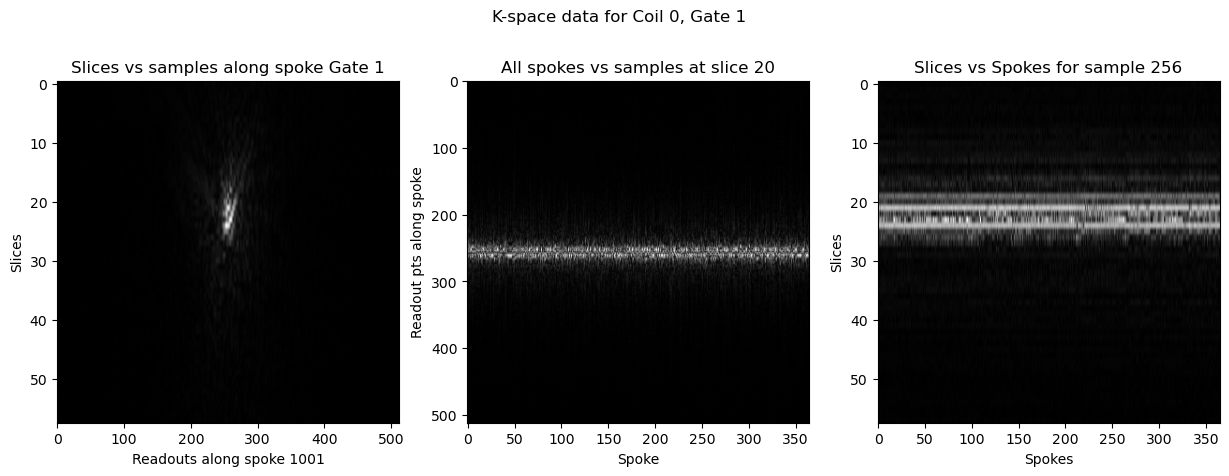

Average value, slices vs samples per gate = 1.6932563216195958e-05
Average value, readouts vs spokes per gate = 3.635571181820448e-05
Average value, slices vs center sample per gate = 0.00014265832696281833


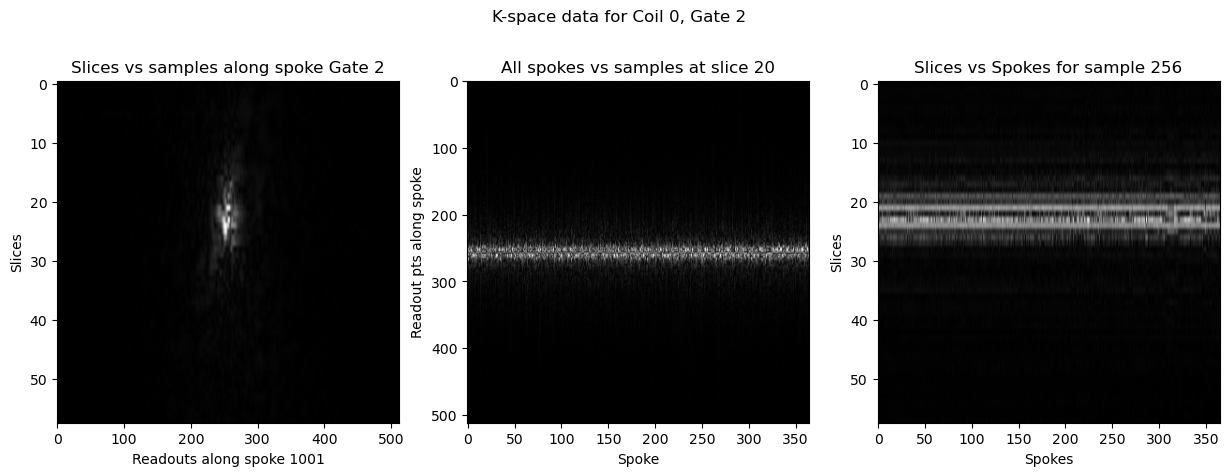

Average value, slices vs samples per gate = 1.6892834123652104e-05
Average value, readouts vs spokes per gate = 3.619347139111623e-05
Average value, slices vs center sample per gate = 0.0001447853020604608


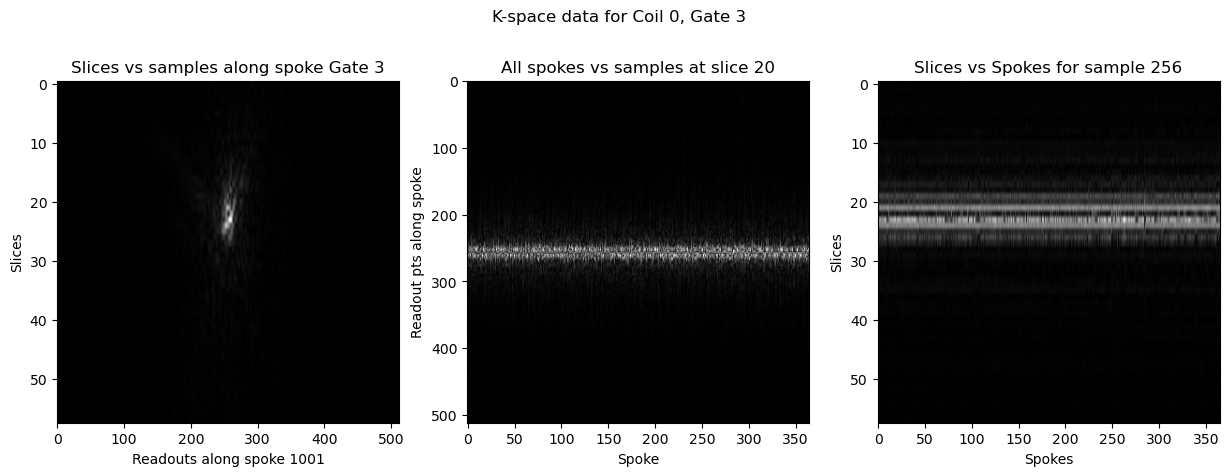

Average value, slices vs samples per gate = 1.936863032766356e-05
Average value, readouts vs spokes per gate = 3.6082829940072515e-05
Average value, slices vs center sample per gate = 0.00014712663976434906


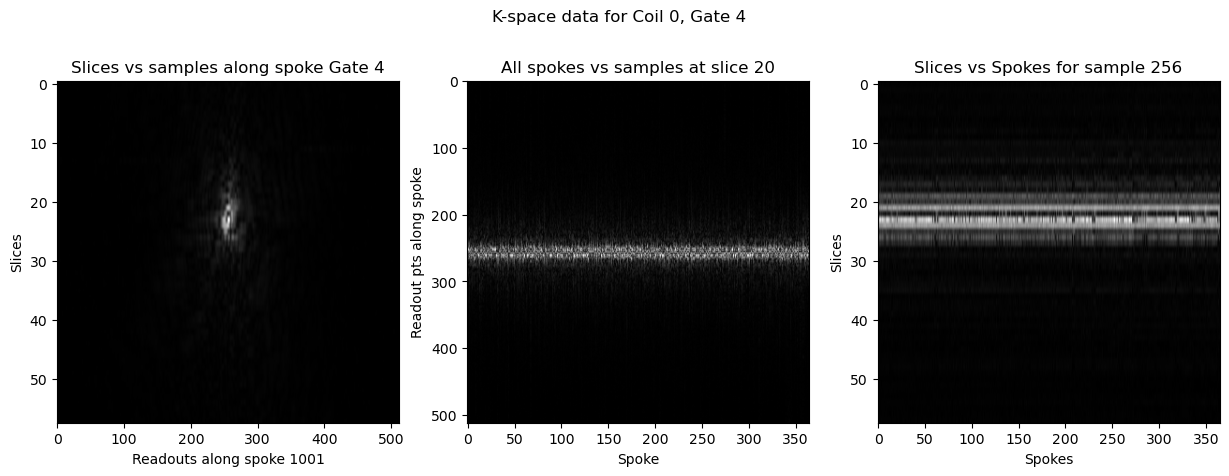

Average value, slices vs samples per gate = 1.8564316498616185e-05
Average value, readouts vs spokes per gate = 3.6279299327594066e-05
Average value, slices vs center sample per gate = 0.00014953671922262454


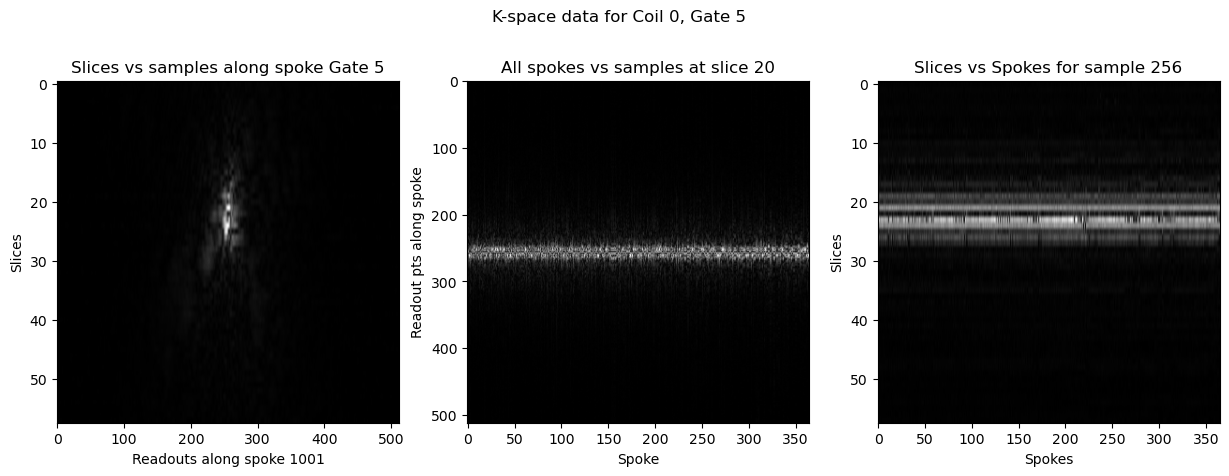

In [8]:
def plot_ksp_data_new(ksp_data, coil_idx, center_slice = None, spoke_idx =0, center_sample = None, title_info=""):

    # ksp_data = ksp_data.transpose(0,2,1,3)
    ## Get all dims 
    ncoils, nslices, nspokes, nsamples= ksp_data.shape

    ## If center idx not given, assume it is middle
    if center_slice is None:
        center_slice = nslices // 2
    
    if center_sample is None:
        center_sample = nsamples //2

    fig, axs = plt.subplots(1, 3, figsize=(15,5))

    ## Plot spokes vs slices
    axs[0].imshow(np.abs(ksp_data[0, :, 0, :]), cmap='gray', aspect=nsamples/nslices)
    print(f'Average value, slices vs samples per gate = {np.mean(np.abs(ksp_data[0, :, 0, :]))}')
    axs[0].set_xlabel(f"Readouts along spoke {spoke_idx}")
    axs[0].set_ylabel("Slices")
    axs[0].set_title(f"Slices vs samples along spoke {title_info}")

    ## Plot spokes vs samples for center idx 
    axs[1].imshow(np.abs(ksp_data[0, center_slice, :, :]).T, cmap='gray', aspect=nspokes/nsamples)
    print(f'Average value, readouts vs spokes per gate = {np.mean(np.abs(ksp_data[0, center_slice, :, :]).T)}')
    axs[1].set_xlabel("Spoke")
    axs[1].set_ylabel("Readout pts along spoke")
    axs[1].set_title(f"All spokes vs samples at slice {center_slice}")

    ## Plot all slices vs center sample
    axs[2].imshow(np.abs(ksp_data[0, :, :, center_sample]), cmap='gray', aspect=nspokes/nslices)
    print(f'Average value, slices vs center sample per gate = {np.mean(np.abs(ksp_data[0, :, :, center_sample]))}')
    axs[2].set_xlabel("Spokes")
    axs[2].set_ylabel("Slices")
    axs[2].set_title(f"Slices vs Spokes for sample {center_sample}")
    
    fig.suptitle(f"K-space data for Coil {coil_idx}, {title_info}")

    plt.show()

for i in range(5):
    plot_ksp_data_new(data_bins[i], coil_idx=0, center_slice=20, spoke_idx=1001
                      , title_info=f"Gate {i+1}")

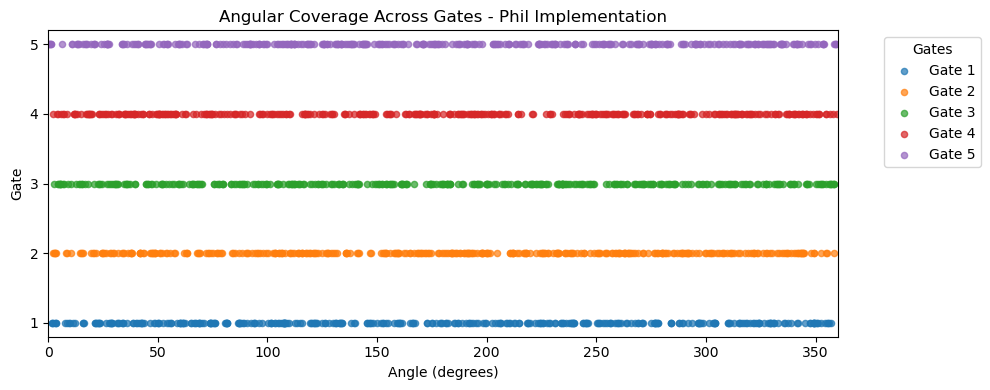

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Example: assuming spoke_bins is a list of arrays, one per gate
# spoke_bins[gate_idx].shape = (num_slices, num_spokes, num_samples, ndims)

num_gates = len(spoke_bins)
middle_slice = 20
num_samples = 512

plt.figure(figsize=(10, 4))

for gate_idx in range(num_gates):
    coords = spoke_bins[gate_idx]
    
    # Extract center of k-space (or first readout point) for middle slice
    kx = coords[middle_slice, :, num_samples//2, 2]  # x
    ky = coords[middle_slice, :, num_samples//2, 1]  # y
    
    # Compute angles in degrees [0, 360)
    angles_deg = np.degrees(np.arctan2(ky, kx)) % 360
    
    # Plot each angle as a dot at the corresponding gate index
    plt.scatter(angles_deg, np.full_like(angles_deg, gate_idx + 1), label=f'Gate {gate_idx + 1}', alpha=0.7, s=20)

plt.xlabel("Angle (degrees)")
plt.ylabel("Gate")
plt.yticks(range(1, num_gates + 1))
plt.xlim(0, 360)
plt.title("Angular Coverage Across Gates - Phil Implementation")
plt.legend(title="Gates", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [9]:
import save_data_helpers

save_data_helpers.write_pickle(data_bins, 'data_bins_phil_gating.pkl')
save_data_helpers.write_pickle(spoke_bins, 'sooke_bins_phil_gating.pkl')

Successfully saved as data_bins_phil_gating.pkl
Successfully saved as sooke_bins_phil_gating.pkl


In [10]:
print(data_bins[0].shape)
print(spoke_bins[0].shape)

(15, 58, 365, 512)
(58, 365, 512, 3)
